# Alzheimer's disease diagnosis - classification track

23CSE301 Machine Learning capstone. Dataset is the Alzheimer's Disease dataset from Kaggle (Rabie El Kharoua), `data/alzheimers_disease_data.csv`, which has 2149 patients and 35 columns.

## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("sklearn", sklearn.__version__)

pandas 2.3.0
numpy 2.0.2
sklearn 1.7.0


## 3. Data loading

In [2]:
df_raw = pd.read_csv("data/alzheimers_disease_data.csv")
print("shape:", df_raw.shape)
df_raw.head()

shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


Dataset Description

- PatientID - patient id (4751 to 6899), not useful so it gets dropped
- Age - age in years, 60 to 90
- Gender - 0 = Male, 1 = Female
- Ethnicity - 0 = Caucasian, 1 = African American, 2 = Asian, 3 = Other
- EducationLevel - 0 = None, 1 = High School, 2 = Bachelor's, 3 = Higher
- BMI - body mass index, 15 to 40
- Smoking - 0 = No, 1 = Yes
- AlcoholConsumption - units per week, 0 to 20
- PhysicalActivity - hours per week, 0 to 10
- DietQuality - diet score, 0 to 10
- SleepQuality - sleep score, 4 to 10
- FamilyHistoryAlzheimers - family history of Alzheimer's, 0/1
- CardiovascularDisease - 0/1
- Diabetes - 0/1
- Depression - 0/1
- HeadInjury - history of head injury, 0/1
- Hypertension - 0/1
- SystolicBP - systolic blood pressure mmHg, 90 to 180
- DiastolicBP - diastolic blood pressure mmHg, 60 to 120
- CholesterolTotal - total cholesterol mg/dL
- CholesterolLDL - LDL ("bad") cholesterol mg/dL
- CholesterolHDL - HDL ("good") cholesterol mg/dL
- CholesterolTriglycerides - triglycerides mg/dL
- MMSE - Mini Mental State Examination, 0 to 30, lower = more cognitive impairment
- FunctionalAssessment - functional assessment score, 0 to 10, lower = more impairment
- MemoryComplaints - patient complains about memory, 0/1
- BehavioralProblems - 0/1
- ADL - Activities of Daily Living score, 0 to 10, lower = more impairment
- Confusion - 0/1
- Disorientation - 0/1
- PersonalityChanges - 0/1
- DifficultyCompletingTasks - 0/1
- Forgetfulness - 0/1
- Diagnosis - the target. 0 = no Alzheimer's, 1 = Alzheimer's
- DoctorInCharge - supposed to be the doctor, but every row just says "XXXConfid" (confidential), so it gets dropped too

In [3]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "non_null": df_raw.notnull().sum(),
    "missing": df_raw.isnull().sum(),
    "missing_%": round(df_raw.isnull().mean() * 100, 1),
    "n_unique": df_raw.nunique()
})
audit

,dtype,non_null,missing,missing_%,n_unique
PatientID,int64,2149,0,0.0,2149
Age,int64,2149,0,0.0,31
Gender,int64,2149,0,0.0,2
Ethnicity,int64,2149,0,0.0,4
EducationLevel,int64,2149,0,0.0,4
BMI,float64,2149,0,0.0,2149
Smoking,int64,2149,0,0.0,2
AlcoholConsumption,float64,2149,0,0.0,2149
PhysicalActivity,float64,2149,0,0.0,2149
DietQuality,float64,2149,0,0.0,2149


In [4]:
# target distribution
print(df_raw["Diagnosis"].value_counts())
print()
print(df_raw["Diagnosis"].value_counts(normalize=True) * 100)

counts = df_raw["Diagnosis"].value_counts()
print()
print("imbalance ratio 0 : 1 =", round(counts[0] / counts[1], 1), ": 1")
print("majority class baseline accuracy =", round(counts.max() / len(df_raw) * 100, 2), "%")

Diagnosis
0    1389
1     760
Name: count, dtype: int64

Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64

imbalance ratio 0 : 1 = 1.8 : 1
majority class baseline accuracy = 64.63 %


In [5]:
df_raw.drop(columns=["PatientID", "DoctorInCharge"]).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,2149.0,74.91,8.99,60.00,67.00,75.00,83.00,90.00
Gender,2149.0,0.51,0.50,0.00,0.00,1.00,1.00,1.00
Ethnicity,2149.0,0.70,1.00,0.00,0.00,0.00,1.00,3.00
EducationLevel,2149.0,1.29,0.90,0.00,1.00,1.00,2.00,3.00
BMI,2149.0,27.66,7.22,15.01,21.61,27.82,33.87,39.99
Smoking,2149.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00
AlcoholConsumption,2149.0,10.04,5.76,0.00,5.14,9.93,15.16,19.99
PhysicalActivity,2149.0,4.92,2.86,0.00,2.57,4.77,7.43,9.99
DietQuality,2149.0,4.99,2.91,0.01,2.46,5.08,7.56,10.00
SleepQuality,2149.0,7.05,1.76,4.00,5.48,7.12,8.56,10.00


### audi obervations

2149 patients and 35 columns.

There are only 2 classes for the target feature Diagnosis:

- 0 = no Alzheimer's (1389 patients)
- 1 = Alzheimer's (760 patients)

There are no missing values at all, every column has all 2149 values.

Almost every continuous column has exactly 2149 unique values (BMI, AlcoholConsumption, MMSE, all four cholesterols...), so no two patients share a value, and the min / max are suspiciously neat ranges (BMI 15 to 40, MMSE 0 to 30, FunctionalAssessment and ADL 0 to 10).

DoctorInCharge only has 1 unique value ("XXXConfid") so it can't carry any information. PatientID just counts up from 4751 to 6899.

Most of the columns are stored as int64 even though they're really categories (Gender, Ethnicity and all the yes/no ones).

## 4. EDA


### 4.1 Target distribution

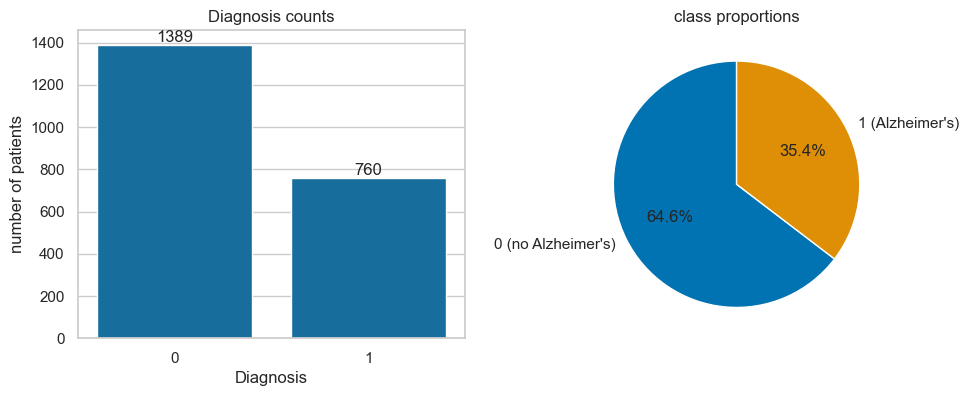

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")

order = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="Diagnosis", data=df_raw, order=order, ax=axes[0])
axes[0].set_title("Diagnosis counts")
axes[0].set_ylabel("number of patients")
for c in axes[0].containers:
    axes[0].bar_label(c)

counts = df_raw["Diagnosis"].value_counts()[order]
axes[1].pie(counts, labels=["0 (no Alzheimer's)", "1 (Alzheimer's)"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("class proportions")

plt.show()

Imbalanced but not by alot: 0 is 64.6%, 1 is 35.4%.

### 4.2 Distribution of each numeric feature

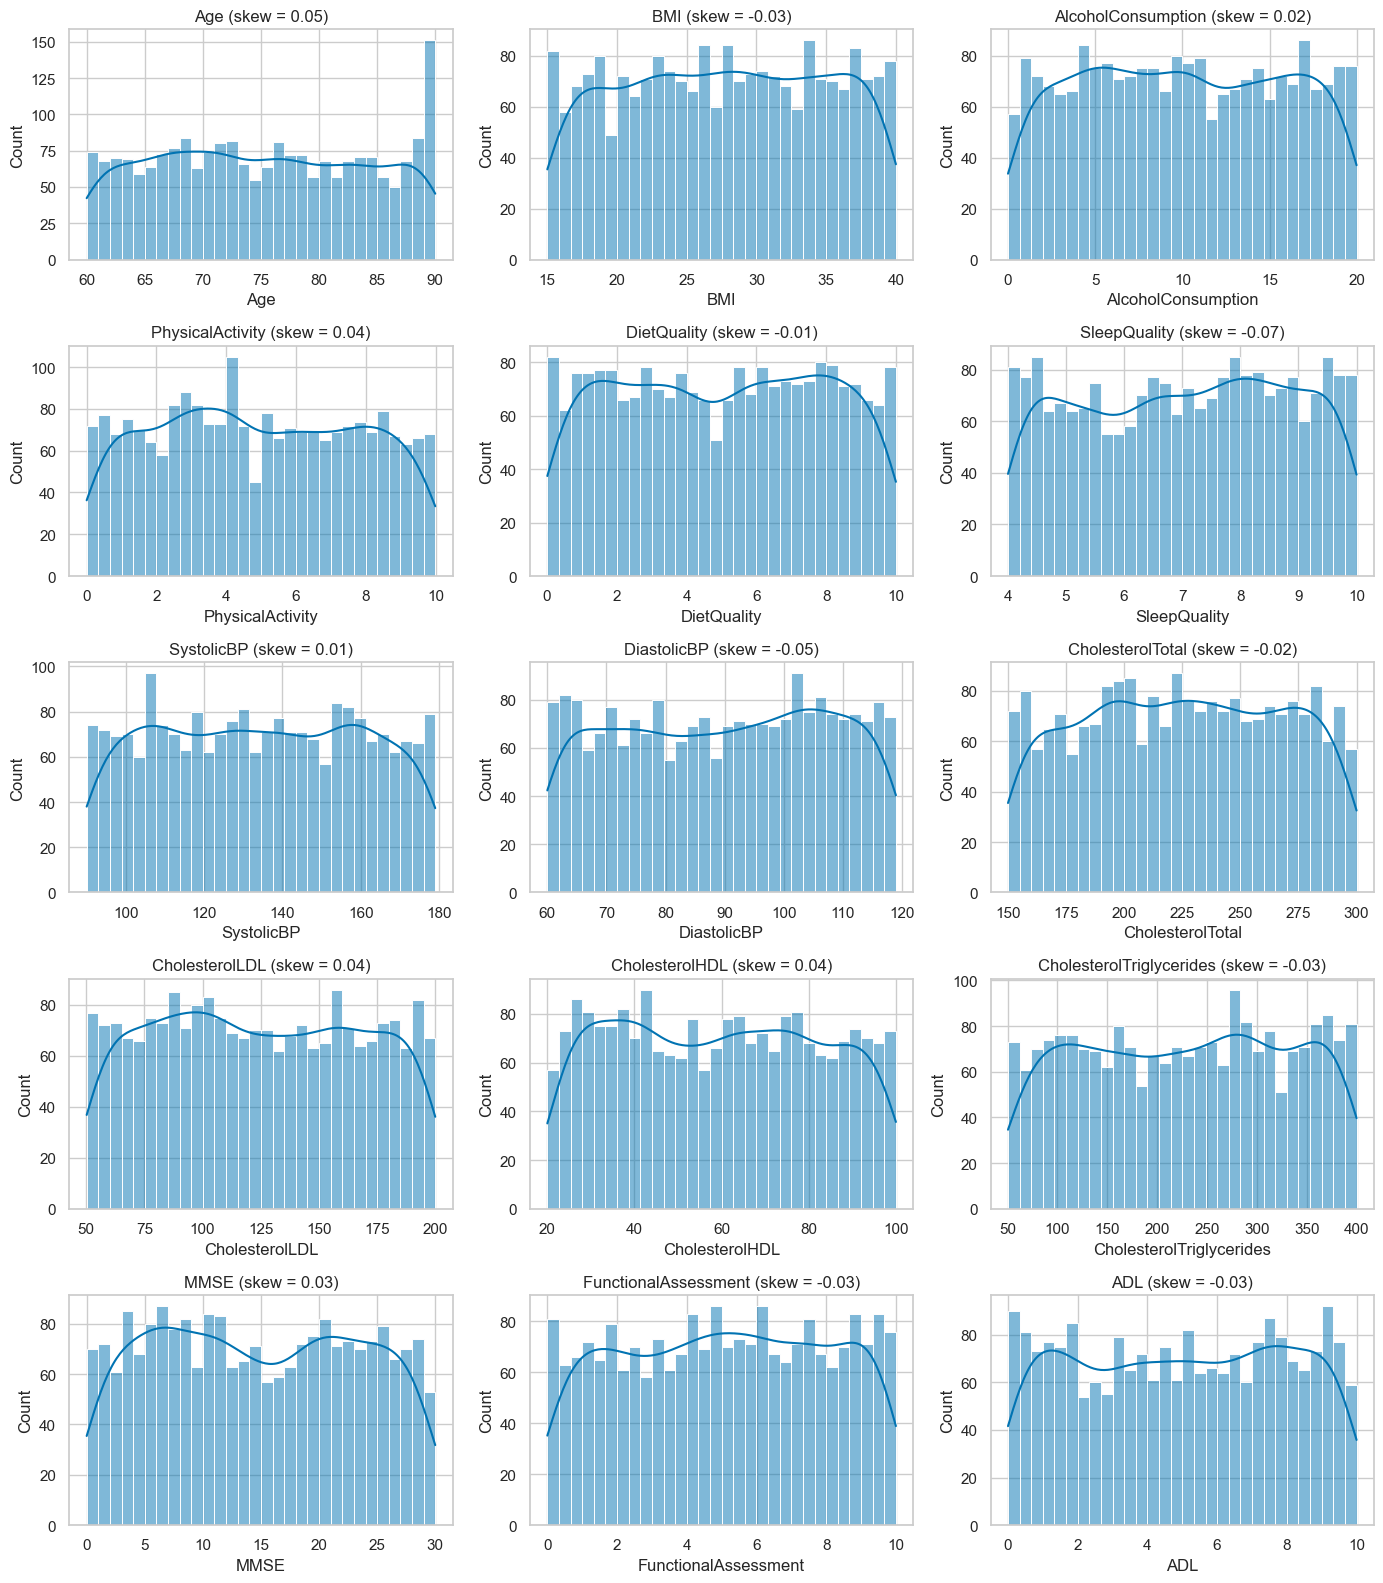

skewness:
Age                         0.05
PhysicalActivity            0.04
CholesterolHDL              0.04
CholesterolLDL              0.04
MMSE                        0.03
AlcoholConsumption          0.02
SystolicBP                  0.01
DietQuality                -0.01
CholesterolTotal           -0.02
BMI                        -0.03
ADL                        -0.03
CholesterolTriglycerides   -0.03
FunctionalAssessment       -0.03
DiastolicBP                -0.05
SleepQuality               -0.07
dtype: float64


In [7]:
# a lot of the columns are 0/1 flags or small codes (ethnicity, education), those aren't really numeric
# so only taking the columns with more than 4 different values
numeric_features = []
for col in df_raw.select_dtypes(include="number").columns:
    if df_raw[col].nunique() > 4 and col != "PatientID":
        numeric_features.append(col)

fig, axes = plt.subplots(5, 3, figsize=(14, 16))
axes = axes.flatten()
for i in range(len(numeric_features)):
    col = numeric_features[i]
    sns.histplot(df_raw[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col + " (skew = " + str(round(df_raw[col].skew(), 2)) + ")")
plt.tight_layout()
plt.show()

print("skewness:")
print(df_raw[numeric_features].skew().sort_values(ascending=False).round(2))

Every numeric feature has a skew between -0.07 and 0.05, so basically zero, and the histograms are flat. They look like uniform distributions, not bell curves and not long tails.

### 4.3 How the numeric features separate the two classes

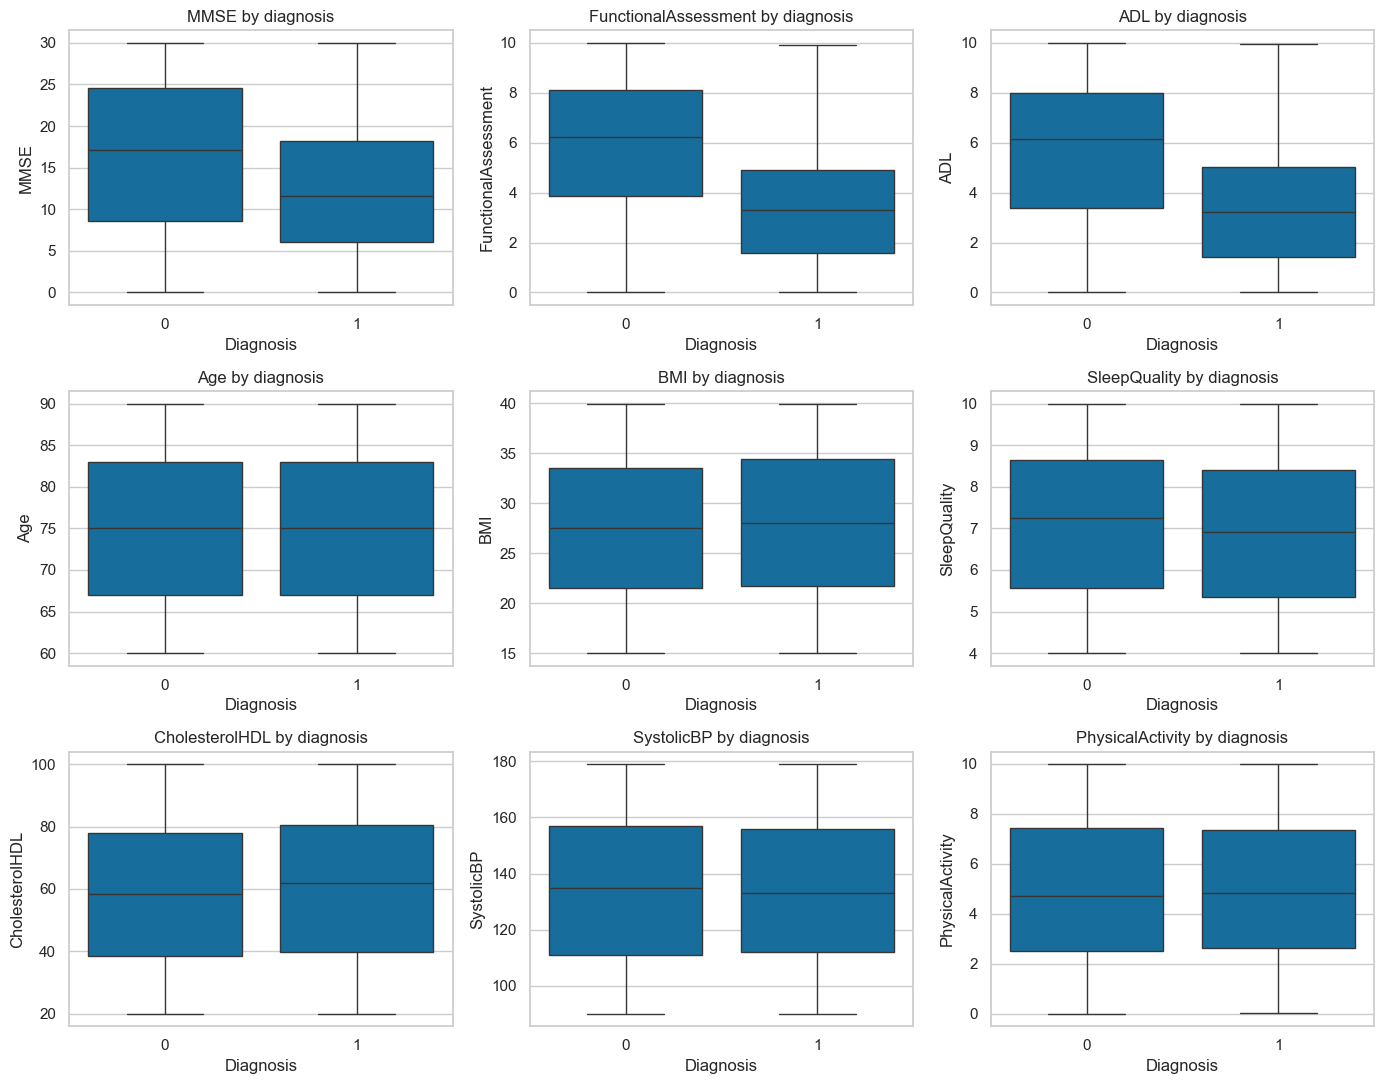

median per class:
            MMSE  FunctionalAssessment   ADL   Age    BMI  SleepQuality  CholesterolHDL  SystolicBP  PhysicalActivity
Diagnosis                                                                                                            
0          17.15                  6.24  6.14  75.0  27.56          7.24           58.30       135.0              4.73
1          11.57                  3.30  3.24  75.0  28.00          6.91           61.85       133.0              4.85


In [8]:
key_features = ["MMSE", "FunctionalAssessment", "ADL", "Age", "BMI", "SleepQuality", "CholesterolHDL", "SystolicBP", "PhysicalActivity"]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
for i in range(len(key_features)):
    col = key_features[i]
    sns.boxplot(x="Diagnosis", y=col, data=df_raw, order=order, ax=axes[i])
    axes[i].set_title(col + " by diagnosis")
    # nothing is skewed in this dataset (4.2) so no log scale needed this time
plt.tight_layout()
plt.show()

print("median per class:")
print(df_raw.groupby("Diagnosis")[key_features].median().round(2))

Only three of these actually separate the classes: MMSE, FunctionalAssessment and ADL. Median MMSE is 17.15 for no Alzheimer's and 11.57 for Alzheimer's, FunctionalAssessment goes from 6.24 to 3.30 and ADL from 6.14 to 3.24. All three go down with Alzheimer's which makes sense, worse cognitive score and less able to do daily things by yourself. FunctionalAssessment and ADL almost halve.

Everything else is basically the same in both groups. Median age is 75.0 in both. BMI (27.56 vs 28.00), SleepQuality (7.24 vs 6.91), HDL, blood pressure and physical activity are all within noise.

Even for the three good features the boxes overlap a lot, so no single feature is enough on its own. Also a median MMSE of 17 for the healthy group is weird.

### 4.4 Scatter plots of features vs target

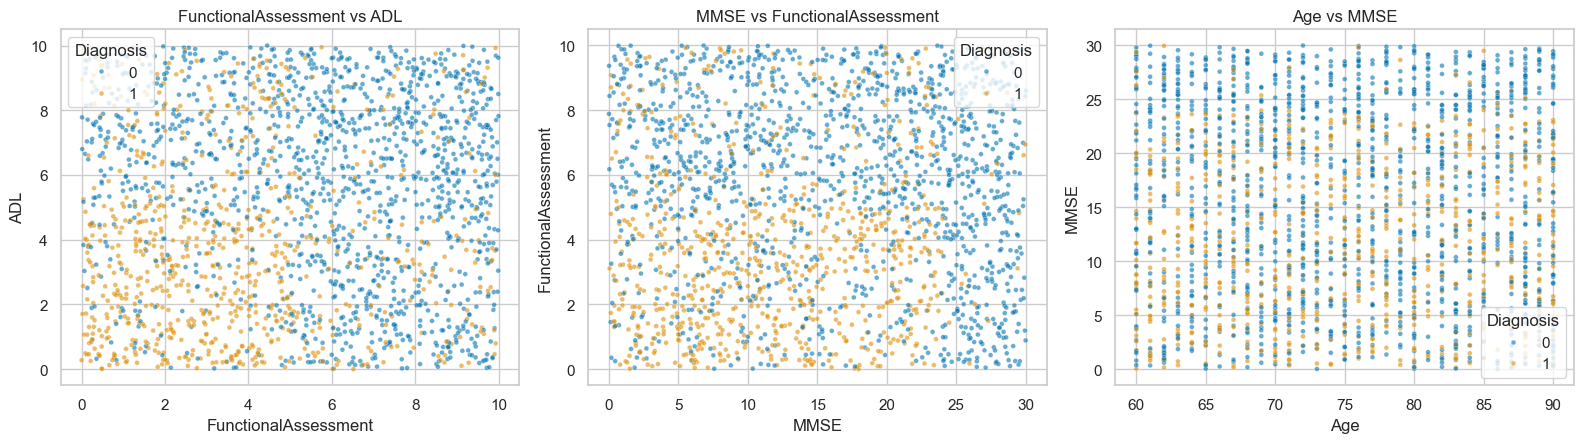

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# 2149 points so making them small and a bit see through
sns.scatterplot(data=df_raw, x="FunctionalAssessment", y="ADL", hue="Diagnosis", hue_order=order, s=12, alpha=0.6, ax=axes[0])
axes[0].set_title("FunctionalAssessment vs ADL")

sns.scatterplot(data=df_raw, x="MMSE", y="FunctionalAssessment", hue="Diagnosis", hue_order=order, s=12, alpha=0.6, ax=axes[1])
axes[1].set_title("MMSE vs FunctionalAssessment")

sns.scatterplot(data=df_raw, x="Age", y="MMSE", hue="Diagnosis", hue_order=order, s=12, alpha=0.6, ax=axes[2])
axes[2].set_title("Age vs MMSE")

plt.tight_layout()
plt.show()

The Alzheimer's patients (orange) are mostly along the bottom and down the left side, so where FunctionalAssessment is below about 5 OR ADL is below about 5. The top right corner, where both are above 5, is almost all blue. So the required separator between the classes would need to be an L shape.

The second plot shows that orange is mostly in the bottom half (FunctionalAssessment below 5) and leans towards the left (lower MMSE), but it's much more mixed than the first plot, which fits MMSE having the weakest correlation of the three.

The third one shows no pattern at all. The orange points are spread evenly over every age from 60 to 90 (the vertical stripes are because age is in whole years).

### 4.5 Categorical features vs the target

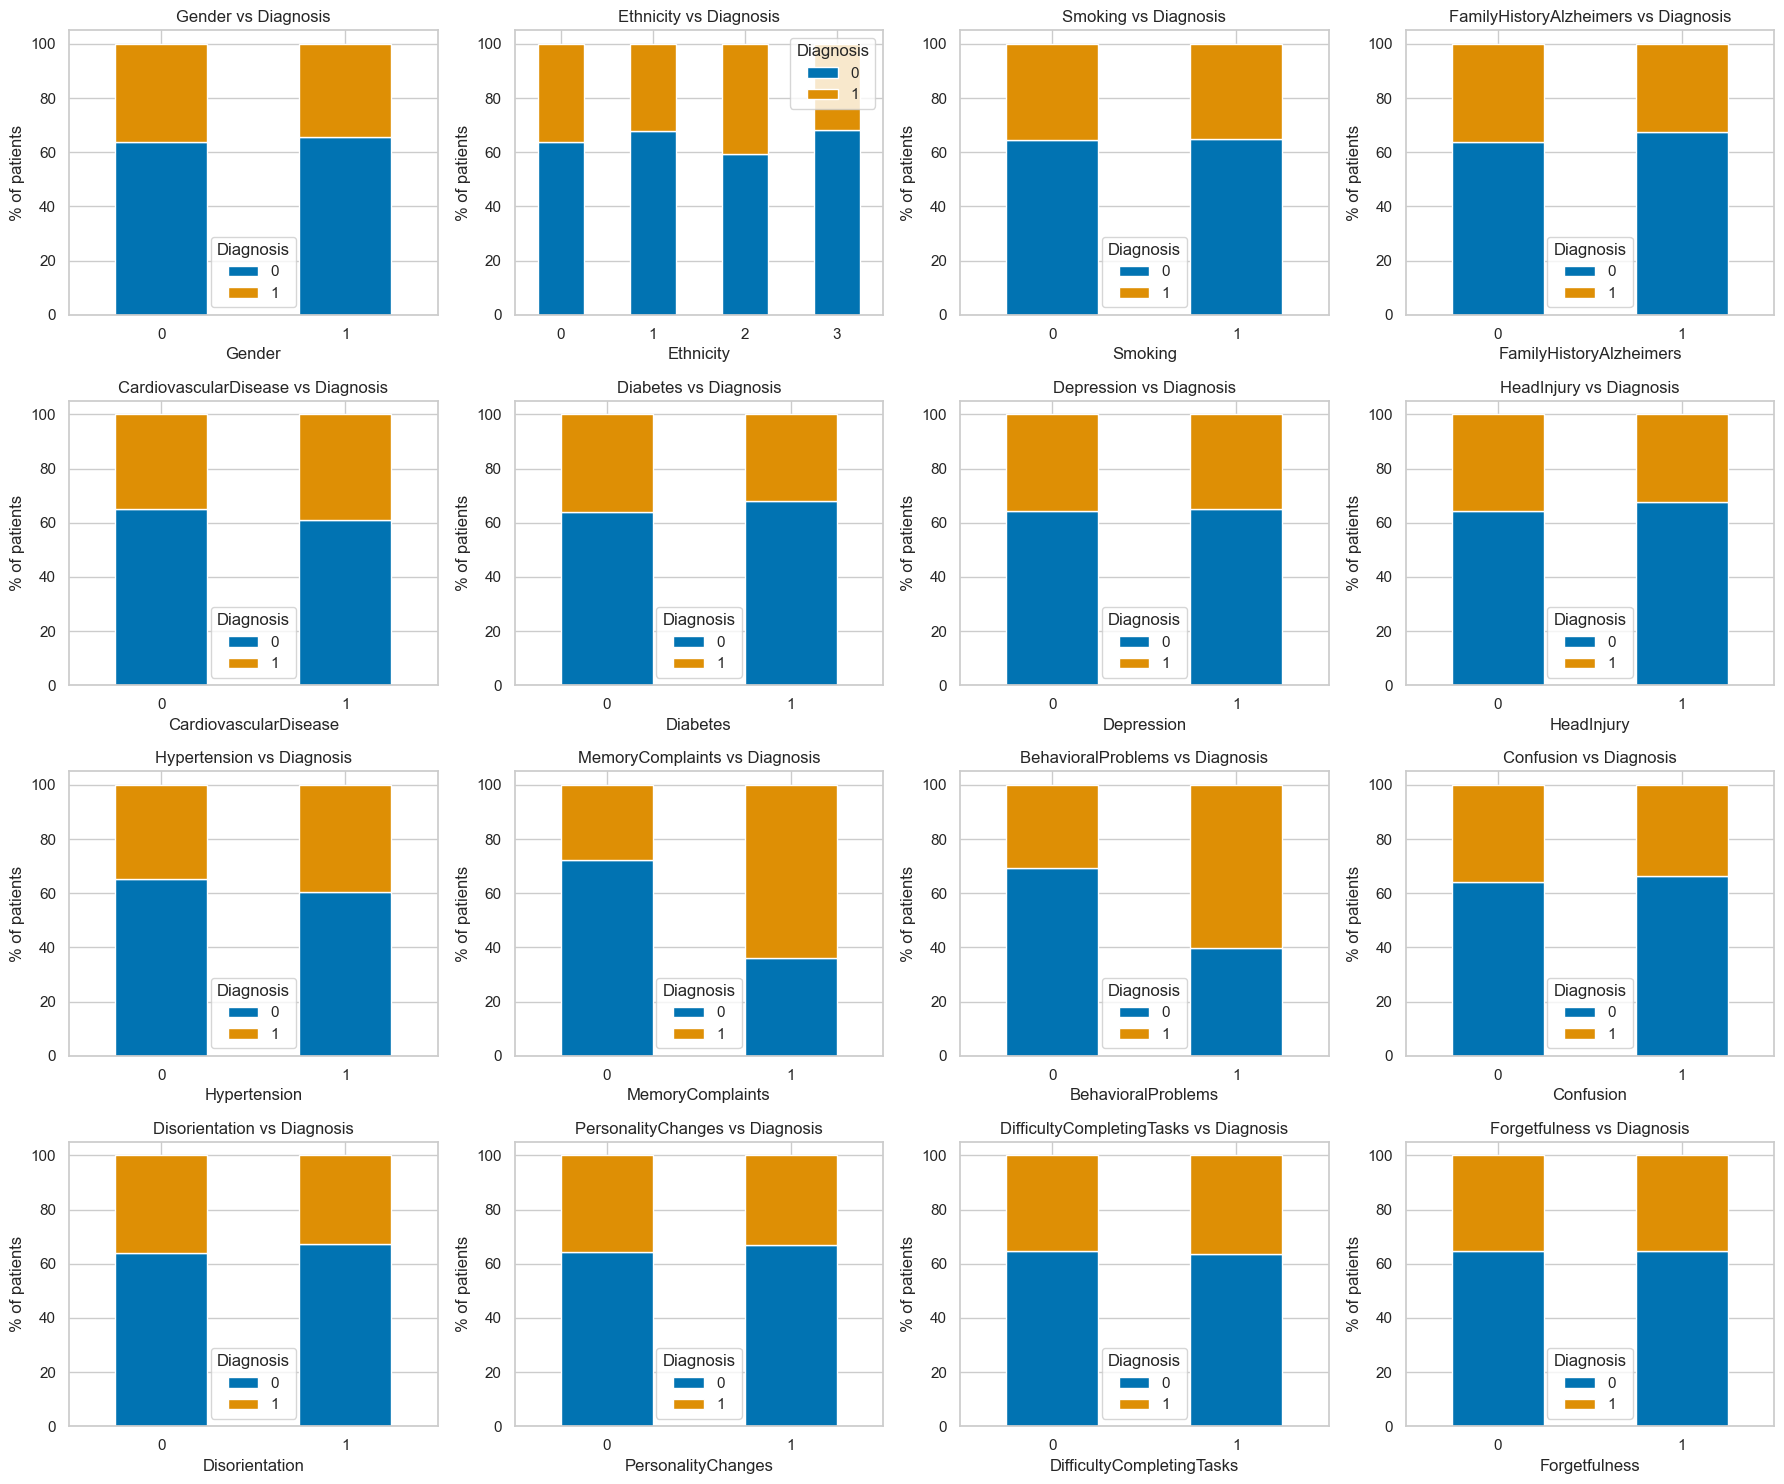

---- Gender ----
Gender
1    1088
0    1061
Name: count, dtype: int64
alzheimer's rate %:
Gender
0    36.4
1    34.4
Name: 1, dtype: float64

---- Ethnicity ----
Ethnicity
0    1278
1     454
3     211
2     206
Name: count, dtype: int64
alzheimer's rate %:
Ethnicity
0    36.2
1    32.2
2    40.8
3    31.8
Name: 1, dtype: float64

---- Smoking ----
Smoking
0    1529
1     620
Name: count, dtype: int64
alzheimer's rate %:
Smoking
0    35.5
1    35.0
Name: 1, dtype: float64

---- FamilyHistoryAlzheimers ----
FamilyHistoryAlzheimers
0    1607
1     542
Name: count, dtype: int64
alzheimer's rate %:
FamilyHistoryAlzheimers
0    36.3
1    32.7
Name: 1, dtype: float64

---- CardiovascularDisease ----
CardiovascularDisease
0    1839
1     310
Name: count, dtype: int64
alzheimer's rate %:
CardiovascularDisease
0    34.7
1    39.0
Name: 1, dtype: float64

---- Diabetes ----
Diabetes
0    1825
1     324
Name: count, dtype: int64
alzheimer's rate %:
Diabetes
0    36.0
1    31.8
Name: 1, dtype: flo

In [10]:
categorical_features = ["Gender", "Ethnicity", "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes",
                        "Depression", "HeadInjury", "Hypertension", "MemoryComplaints", "BehavioralProblems",
                        "Confusion", "Disorientation", "PersonalityChanges", "DifficultyCompletingTasks", "Forgetfulness"]

fig, axes = plt.subplots(4, 4, figsize=(18, 15))
axes = axes.flatten()
for i in range(len(categorical_features)):
    col = categorical_features[i]
    ct = pd.crosstab(df_raw[col], df_raw["Diagnosis"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i])
    axes[i].set_title(col + " vs Diagnosis")
    axes[i].set_ylabel("% of patients")
    axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

for col in categorical_features:
    print("----", col, "----")
    print(df_raw[col].value_counts())
    print("alzheimer's rate %:")
    print((pd.crosstab(df_raw[col], df_raw["Diagnosis"], normalize="index")[1] * 100).round(1))
    print()

Only two of the sixteen matter: MemoryComplaints and BehavioralProblems. 64.0% of the patients with memory complaints have Alzheimer's vs 27.8% without, and 60.2% of the ones with behavioural problems vs 30.7% without.

### 4.6 Correlation heatmap

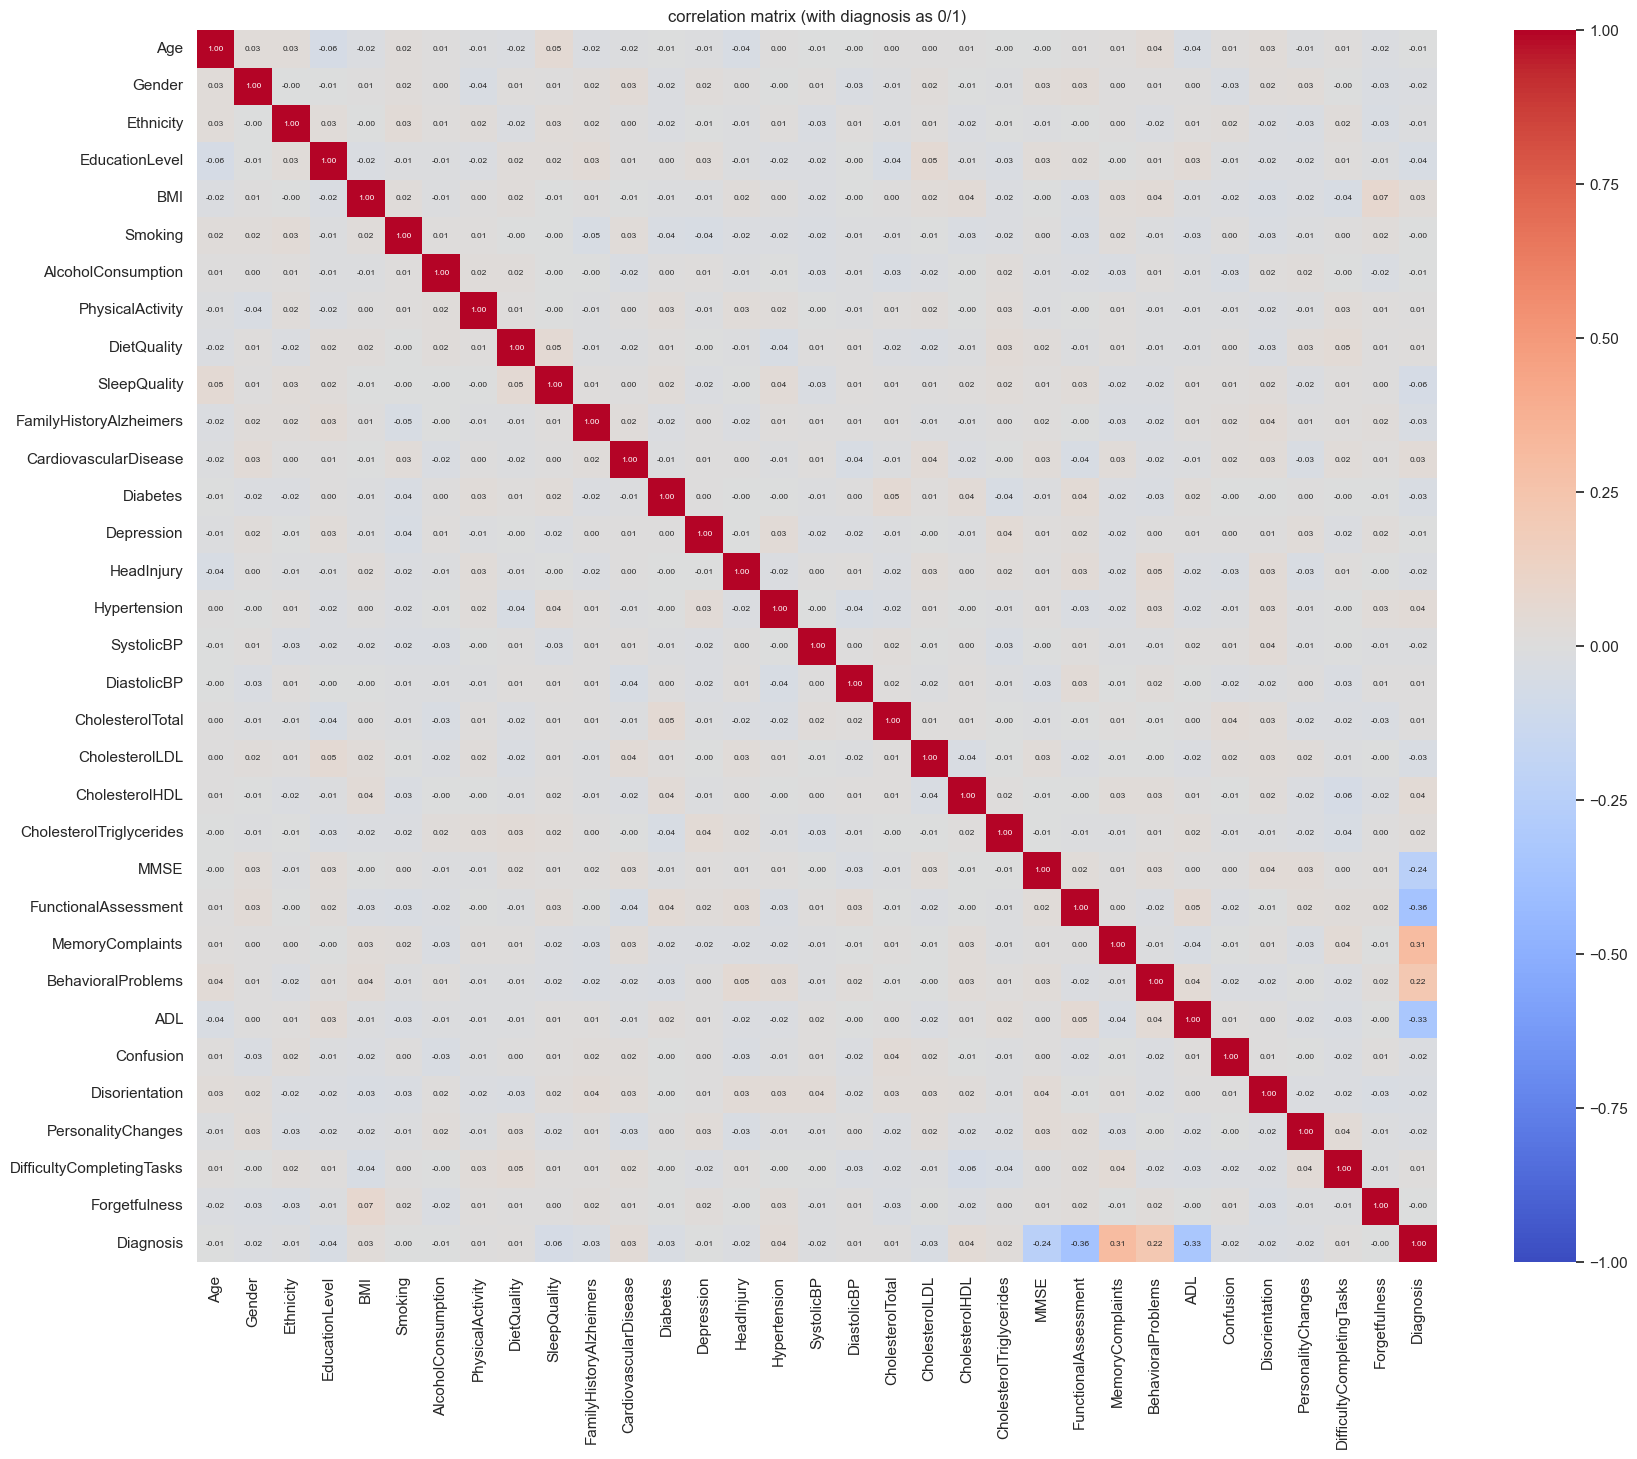

correlation with diagnosis:
MemoryComplaints             0.307
BehavioralProblems           0.224
CholesterolHDL               0.043
Hypertension                 0.035
CardiovascularDisease        0.031
BMI                          0.026
CholesterolTriglycerides     0.023
DifficultyCompletingTasks    0.009
DietQuality                  0.009
CholesterolTotal             0.006
PhysicalActivity             0.006
DiastolicBP                  0.005
Forgetfulness               -0.000
Smoking                     -0.005
Age                         -0.005
Depression                  -0.006
AlcoholConsumption          -0.008
Ethnicity                   -0.015
SystolicBP                  -0.016
Confusion                   -0.019
PersonalityChanges          -0.021
Gender                      -0.021
HeadInjury                  -0.021
Disorientation              -0.025
Diabetes                    -0.032
CholesterolLDL              -0.032
FamilyHistoryAlzheimers     -0.033
EducationLevel             

In [ ]:
corr_df = df_raw.drop(columns=["PatientID", "DoctorInCharge"]).select_dtypes(include="number")
corr = corr_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, annot_kws={"size": 6})
plt.title("correlation matrix (with diagnosis as 0/1)")
plt.show()

print("correlation with diagnosis:")
print(corr["Diagnosis"].drop("Diagnosis").sort_values(ascending=False).round(3))



There is no Multicollinearity


## 6. Data cleaning

duplicate IDs: 0
duplicate rows (ignoring ID): 0

total missing values: 0
columns with at least one missing value: 0


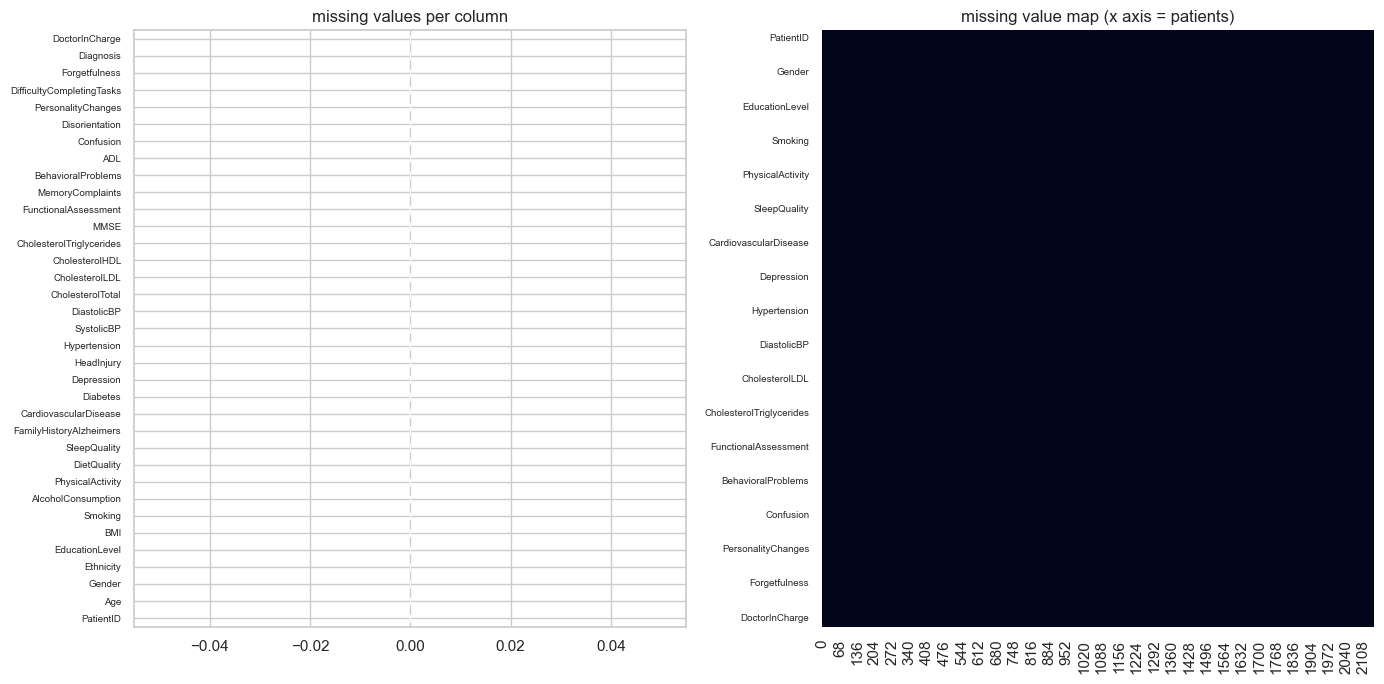

DoctorInCharge value counts:
DoctorInCharge
XXXConfid    2149
Name: count, dtype: int64


In [13]:
# duplicates
print("duplicate IDs:", df_raw["PatientID"].duplicated().sum())
print("duplicate rows (ignoring ID):", df_raw.drop(columns=["PatientID"]).duplicated().sum())

# missing values
missing = df_raw.isnull().sum()
print()
print("total missing values:", missing.sum())
print("columns with at least one missing value:", (missing > 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
missing.plot(kind="barh", ax=axes[0])
axes[0].set_title("missing values per column")
axes[0].tick_params(axis="y", labelsize=7)
sns.heatmap(df_raw.isnull().T, cbar=False, ax=axes[1])
axes[1].set_title("missing value map (x axis = patients)")
axes[1].tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

# the doctor column - is it really the same thing in every row?
print("DoctorInCharge value counts:")
print(df_raw["DoctorInCharge"].value_counts())

No duplicates at all, 0 duplicate IDs and 0 duplicate records, so nothing to remove.

No missing values either. The bar chart is all zeros and the missing value map is completely empty, so there's nothing to impute and nothing to delete. We still keep the imputers inside the pipeline (section 8) so that the saved model doesn't crash if a new patient comes in with a gap, it doesn't cost anything.

DoctorInCharge is "XXXConfid" for all 2149 patients, so it's been anonymised and has no information. It gets dropped.

In [14]:
# outliers using the IQR rule
for col in numeric_features:
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = ((df_raw[col] < low) | (df_raw[col] > high)).sum()
    pct = round(100 * n_out / df_raw[col].notnull().sum(), 1)
    print(col, ":", n_out, "outliers (", pct, "% )   fences:", round(low, 2), "to", round(high, 2), "  max:", df_raw[col].max())

Age : 0 outliers ( 0.0 % )   fences: 43.0 to 107.0   max: 90
BMI : 0 outliers ( 0.0 % )   fences: 3.22 to 52.26   max: 39.99276746402374
AlcoholConsumption : 0 outliers ( 0.0 % )   fences: -9.89 to 30.19   max: 19.98929335906197
PhysicalActivity : 0 outliers ( 0.0 % )   fences: -4.72 to 14.71   max: 9.987429413422252
DietQuality : 0 outliers ( 0.0 % )   fences: -5.19 to 15.21   max: 9.99834567881401
SleepQuality : 0 outliers ( 0.0 % )   fences: 0.86 to 13.18   max: 9.99984031668144
SystolicBP : 0 outliers ( 0.0 % )   fences: 44.5 to 224.5   max: 179
DiastolicBP : 0 outliers ( 0.0 % )   fences: 27.5 to 151.5   max: 119
CholesterolTotal : 0 outliers ( 0.0 % )   fences: 82.58 to 369.7   max: 299.99335247432657
CholesterolLDL : 0 outliers ( 0.0 % )   fences: -24.61 to 273.54   max: 199.96566510142804
CholesterolHDL : 0 outliers ( 0.0 % )   fences: -20.67 to 138.7   max: 99.98032407804152
CholesterolTriglycerides : 0 outliers ( 0.0 % )   fences: -128.3 to 580.72   max: 399.9418615941332
MMS

0 outliers in every single numeric column. The IQR fences are way outside the actual range of the data, for example MMSE's fences are -15.32 to 44.65 but the scores only go from 0 to 30.

That's what happens with uniform distributions: they have no tails, so nothing is ever far from the middle. In the cirrhosis data we had to decide what to do with extreme patients, here there's nothing to handle, no clipping and no log transforms. (Honestly it's one more sign the data is synthetic, real clinical values basically always have some outliers.)

## 7. Feature engineering

In [15]:
def engineer_features(frame):
    out = frame.copy()

    # 1. MMSE below 24 is the usual clinical cutoff for "cognitive impairment"
    # gives the models the cutoff doctors actually use instead of making them find it
    out["MMSE_Impaired"] = (out["MMSE"] < 24).astype(int)

    # 2. cognitive + functional index, all three assessments put on a 0-1 scale and added (0 to 3, lower = worse)
    # MMSE is out of 30, FunctionalAssessment and ADL are out of 10
    # a bit like a combined severity score, one number instead of three
    out["Cog_Func_Index"] = out["MMSE"] / 30 + out["FunctionalAssessment"] / 10 + out["ADL"] / 10

    # 3. clinical flags - memory complaints + behavioural problems (0 to 2)
    # these are the two yes/no things a doctor would notice in the appointment
    out["Clinical_Flags"] = out["MemoryComplaints"] + out["BehavioralProblems"]

    # 4. symptom count - how many of the 5 cognitive symptoms the patient has (0 to 5)
    # lets a linear model use "more symptoms = more likely" without interaction terms
    out["Symptom_Count"] = (out["Confusion"] + out["Disorientation"] + out["PersonalityChanges"]
                            + out["DifficultyCompletingTasks"] + out["Forgetfulness"])

    # 5. risk factor count - how many of the known risk factors from the medical history (0 to 7)
    out["Risk_Factor_Count"] = (out["FamilyHistoryAlzheimers"] + out["CardiovascularDisease"] + out["Diabetes"]
                                + out["Depression"] + out["HeadInjury"] + out["Hypertension"] + out["Smoking"])

    # no log transforms this time, nothing is skewed (section 6)

    # turning the 0/1 codes into labels so the one hot encoder treats them as categories and not numbers
    # (ethnicity 0-3 isn't in any order, "Asian" isn't 2x "African American")
    out["Gender"] = out["Gender"].map({0: "Male", 1: "Female"})
    out["Ethnicity"] = out["Ethnicity"].map({0: "Caucasian", 1: "African_American", 2: "Asian", 3: "Other"})
    for col in ["Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes", "Depression",
                "HeadInjury", "Hypertension", "MemoryComplaints", "BehavioralProblems", "Confusion",
                "Disorientation", "PersonalityChanges", "DifficultyCompletingTasks", "Forgetfulness"]:
        out[col] = out[col].map({0: "N", 1: "Y"})

    return out


df = engineer_features(df_raw)

engineered = ["MMSE_Impaired", "Cog_Func_Index", "Clinical_Flags", "Symptom_Count", "Risk_Factor_Count"]
df[engineered].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
MMSE_Impaired,2149.0,0.807,0.395,0.000,1.000,1.000,1.000,1.000
Cog_Func_Index,2149.0,1.498,0.517,0.135,1.137,1.516,1.859,2.871
Clinical_Flags,2149.0,0.365,0.542,0.000,0.000,0.000,1.000,2.000
Symptom_Count,2149.0,0.974,0.864,0.000,0.000,1.000,1.000,4.000
Risk_Factor_Count,2149.0,1.278,0.985,0.000,1.000,1.000,2.000,6.000


## 8. Feature selection, train/test split, preprocessing pipeline

In [17]:
# final feature list
# dropped: PatientID (just an index) and DoctorInCharge (same value in every row), see section 5
# all the raw columns are kept this time, the engineered ones are added on top
# (there were no log versions to swap in like you'd do with skewed data)
NUMERIC_COLS = ["Age", "EducationLevel", "BMI", "AlcoholConsumption", "PhysicalActivity", "DietQuality",
                "SleepQuality", "SystolicBP", "DiastolicBP", "CholesterolTotal", "CholesterolLDL",
                "CholesterolHDL", "CholesterolTriglycerides", "MMSE", "FunctionalAssessment", "ADL",
                "MMSE_Impaired", "Cog_Func_Index", "Clinical_Flags", "Symptom_Count", "Risk_Factor_Count"]
CATEGORICAL_COLS = ["Gender", "Ethnicity", "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease",
                    "Diabetes", "Depression", "HeadInjury", "Hypertension", "MemoryComplaints",
                    "BehavioralProblems", "Confusion", "Disorientation", "PersonalityChanges",
                    "DifficultyCompletingTasks", "Forgetfulness"]

X = df[NUMERIC_COLS + CATEGORICAL_COLS]
y = df["Diagnosis"]

print("X shape:", X.shape, "-", len(NUMERIC_COLS), "numeric,", len(CATEGORICAL_COLS), "categorical")
print("classes:", sorted(y.unique()))

X shape: (2149, 37) - 21 numeric, 16 categorical
classes: [np.int64(0), np.int64(1)]


In [18]:
# stratify=y so both sets keep the same 65/35 class mix
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("train:", X_train.shape[0], "patients")
print("test:", X_test.shape[0], "patients")
print()
print("train class counts:")
print(y_train.value_counts())
print()
print("test class counts:")
print(y_test.value_counts())

train: 1719 patients
test: 430 patients

train class counts:
Diagnosis
0    1111
1     608
Name: count, dtype: int64

test class counts:
Diagnosis
0    278
1    152
Name: count, dtype: int64


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# numeric: median impute then scale
# there are no missing values in this dataset, but the imputer stays in so the saved model doesn't crash on a new patient with a gap
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical: missing becomes its own category (same reason as above) then one hot
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Not_recorded")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_COLS),
    ("cat", categorical_pipeline, CATEGORICAL_COLS)
])

# fitting once here only to see the feature names after one hot encoding
# every model gets its own fresh copy inside its pipeline later
preprocessor.fit(X_train)
FEATURE_NAMES = []
for name in preprocessor.get_feature_names_out():
    FEATURE_NAMES.append(name.split("__")[1])

print(len(FEATURE_NAMES), "features after encoding:")
print(FEATURE_NAMES)

40 features after encoding:
['Age', 'EducationLevel', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL', 'MMSE_Impaired', 'Cog_Func_Index', 'Clinical_Flags', 'Symptom_Count', 'Risk_Factor_Count', 'Gender_Male', 'Ethnicity_African_American', 'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Other', 'Smoking_Y', 'FamilyHistoryAlzheimers_Y', 'CardiovascularDisease_Y', 'Diabetes_Y', 'Depression_Y', 'HeadInjury_Y', 'Hypertension_Y', 'MemoryComplaints_Y', 'BehavioralProblems_Y', 'Confusion_Y', 'Disorientation_Y', 'PersonalityChanges_Y', 'DifficultyCompletingTasks_Y', 'Forgetfulness_Y']


Why we set it up like this:

One hot encoding for all the categoricals because none of them are ordinal in a way a single number would capture properly. Ethnicity is the main one, it was stored as 0 to 3, which would make a linear model think "Other" is 3x "African American". drop="if_binary" avoids an extra useless column for all the yes/no ones, and handle_unknown="ignore" means it won't crash if some new category shows up.

EducationLevel is kept as one numeric column instead of one hot, because it really is ordinal: none < high school < bachelor's < higher. Studies say more education = lower risk, and it goes that way here too, just a tiny bit (correlation -0.044). Keeping it as a number lets the linear models use that with one coefficient instead of three.

StandardScaler is applied for every model, trees included. Logistic regression, KNN, SVM and MLP need scaling, and for the tree models it just doesn't matter. Using the same preprocessor for all of them keeps the 10 way comparison fair, which is what the guidelines want.

## 9. Evaluation

One function computes all the required metrics so every model is scored the same way:

- accuracy - required, but inflated by the 64.6% majority class, so never look at it alone
- precision / recall / F1 (weighted) - weighted by how many of each class there are, this is our main metric (same as the cirrhosis notebook so the two are comparable)
- macro F1 - not weighted, so the Alzheimer's class counts just as much as the healthy one
- ROC-AUC - required, uses the predicted probability of class 1 so it rewards being close to right. Only 2 classes this time so no one vs rest needed
- confusion matrix - the only thing that shows how many Alzheimer's patients were missed

In [20]:
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

CLASS_LABELS = [0, 1]

# all the scores and fitted models get saved in these
results = {}
fitted_models = {}


def evaluate_model(name, model, part, notes=""):
    pipe = Pipeline([("preprocessor", clone(preprocessor)), ("model", model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    # only 2 classes so just the probability of class 1
    roc = roc_auc_score(y_test, y_proba[:, 1])

    results[name] = {"Part": part, "Accuracy": acc, "Precision": prec, "Recall": rec,
                     "F1": f1, "Macro F1": macro_f1, "ROC-AUC": roc, "Notes": notes}
    fitted_models[name] = {"pipeline": pipe, "y_pred": y_pred, "y_proba": y_proba}

    print(name)
    print("accuracy:", round(acc, 4), " precision:", round(prec, 4), " recall:", round(rec, 4))
    print("f1:", round(f1, 4), " macro f1:", round(macro_f1, 4), " roc-auc:", round(roc, 4))
    print()
    print(classification_report(y_test, y_pred, zero_division=0))
    print("confusion matrix (rows = true 0/1, cols = predicted 0/1):")
    print(confusion_matrix(y_test, y_pred, labels=CLASS_LABELS))
    return pipe


def plot_confusion(name, ax, normalize=None):
    cm = confusion_matrix(y_test, fitted_models[name]["y_pred"], labels=CLASS_LABELS, normalize=normalize)
    if normalize:
        fmt = ".2f"
    else:
        fmt = "d"
    ConfusionMatrixDisplay(cm, display_labels=CLASS_LABELS).plot(ax=ax, cmap="Blues", colorbar=False, values_format=fmt)
    ax.set_title(name + "\nacc = " + str(round(results[name]["Accuracy"], 3)) + ", f1 = " + str(round(results[name]["F1"], 3)), fontsize=9)
    ax.grid(False)

# Part A - review 1 algorithms

Five algorithms, all trained on the same training set and tested on the same test set.

1. Logistic regression - assumes a linear boundary in log-odds
2. KNN - assumes patients that are close in feature space have the same outcome
3. Gaussian naive bayes - assumes features are gaussian and independent given the class
4. Decision tree - splits the data with a bunch of threshold rules
5. SVM - maximum margin boundary, possibly after a kernel

## 10. Algorithm 1 - Logistic regression (baseline)

In [21]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
logreg_pipe = evaluate_model("Logistic Regression", logreg, "A", "Linear baseline")

Logistic Regression
accuracy: 0.8884  precision: 0.8876  recall: 0.8884
f1: 0.8877  macro f1: 0.8764  roc-auc: 0.9335

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       278
           1       0.86      0.82      0.84       152

    accuracy                           0.89       430
   macro avg       0.88      0.87      0.88       430
weighted avg       0.89      0.89      0.89       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[258  20]
 [ 28 124]]


top 8 features pushing towards 1 = alzheimer's (odds ratio per 1 std):
MMSE_Impaired                  6.789
Clinical_Flags                 4.911
MemoryComplaints_Y             1.607
MMSE                           1.556
BehavioralProblems_Y           1.446
CardiovascularDisease_Y        1.377
Ethnicity_Asian                1.319
DifficultyCompletingTasks_Y    1.292
dtype: float64

top 8 features pushing towards 0 = no alzheimer's (odds ratio per 1 std):
FunctionalAssessment          0.333
ADL                           0.367
Cog_Func_Index                0.392
HeadInjury_Y                  0.770
Ethnicity_Other               0.830
Age                           0.834
CholesterolLDL                0.860
Ethnicity_African_American    0.872
dtype: float64


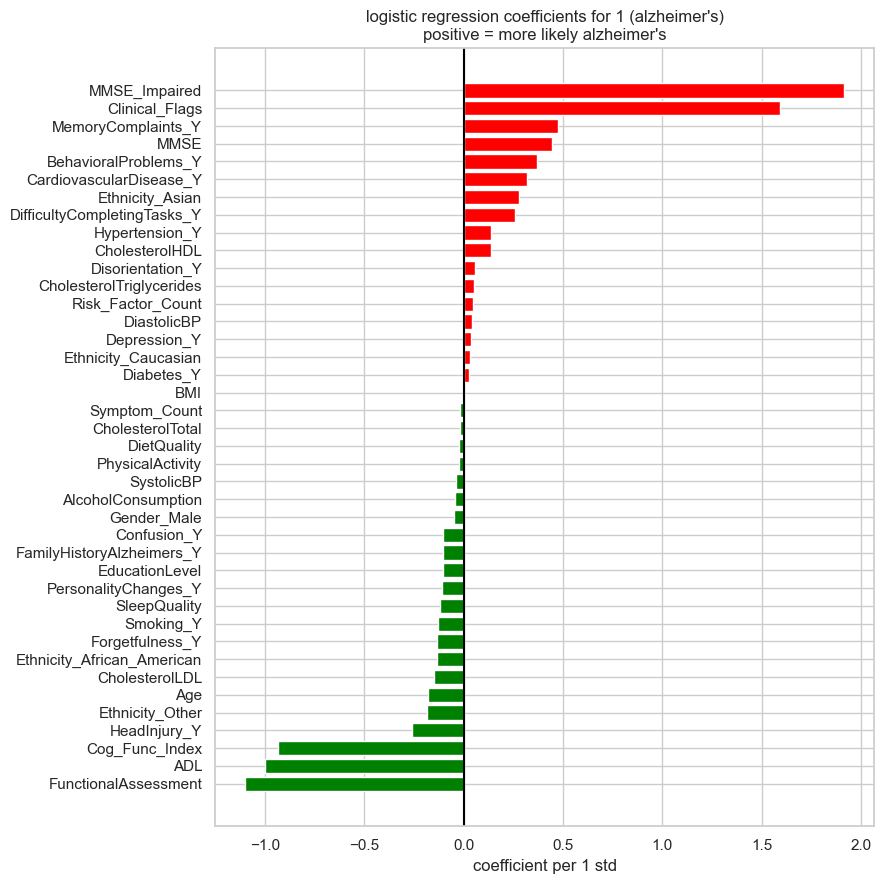

In [22]:
# coefficients / odds ratios
# binary logreg only has one set of coefficients (for class 1)
# exp(coef) = how much the odds of alzheimer's get multiplied for +1 standard deviation of the feature
coefs = pd.Series(logreg_pipe.named_steps["model"].coef_[0], index=FEATURE_NAMES)
odds = np.exp(coefs)

print("top 8 features pushing towards 1 = alzheimer's (odds ratio per 1 std):")
print(odds.sort_values(ascending=False).head(8).round(3))
print()
print("top 8 features pushing towards 0 = no alzheimer's (odds ratio per 1 std):")
print(odds.sort_values().head(8).round(3))

coefs_sorted = coefs.sort_values()
colors = []
for v in coefs_sorted:
    if v < 0:
        colors.append("green")
    else:
        colors.append("red")

plt.figure(figsize=(9, 9))
plt.barh(coefs_sorted.index, coefs_sorted.values, color=colors)
plt.axvline(0, color="black")
plt.title("logistic regression coefficients for 1 (alzheimer's)\npositive = more likely alzheimer's")
plt.xlabel("coefficient per 1 std")
plt.tight_layout()
plt.show()

The coefficients are mostly readable and make sense clinically, which is the main reason to keep a linear baseline in the comparison.

For Alzheimer's the biggest odds ratios are MMSE_Impaired (6.79) and Clinical_Flags (4.91). Taking the second one, one standard deviation more Clinical_Flags (about 0.54, so roughly half a flag) multiplies the odds of Alzheimer's by almost 5. On the other side are FunctionalAssessment (0.33), ADL (0.37) and Cog_Func_Index (0.39), so one standard deviation higher functional score cuts the odds to about a third. That's what the boxplots in 4.3 showed.

One thing that looks wrong: MMSE itself has an odds ratio of 1.56, meaning a *higher* MMSE (better cognition) pushes towards Alzheimer's. That's backwards. It's collinearity again. We built MMSE_Impaired and Cog_Func_Index out of MMSE, so three features now carry overlapping information, and once those two already have the "low MMSE = bad" effect, the leftover raw MMSE coefficient ends up correcting them and flips sign. Same thing with MemoryComplaints_Y (1.61) and BehavioralProblems_Y (1.45), they look small because Clinical_Flags took most of their credit.

The small ones like CardiovascularDisease_Y (1.38) and Ethnicity_Asian (1.32) are most likely noise, given what we saw in 4.5.

So individual coefficients in a collinear model have to be read as a group, not one by one, and they're correlation not causation. That's also why section 23.3 uses permutation importance as the more reliable ranking.

## 11. Algorithm 2 - KNN

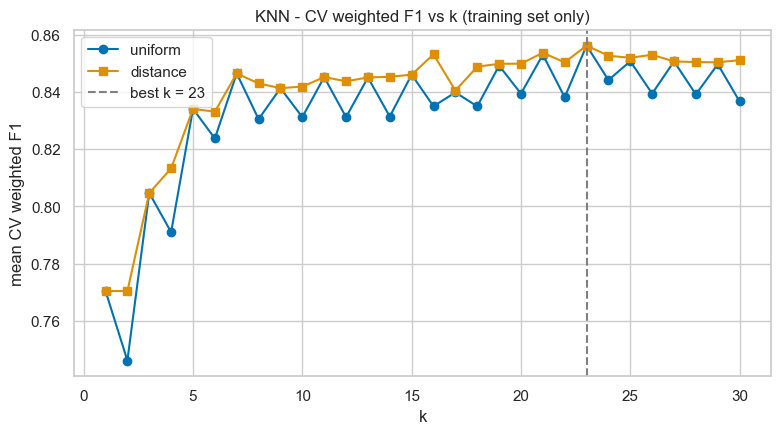

best k = 23  CV f1 = 0.8564


In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# trying k = 1 to 30 with 5 fold CV on the training set only, for both weight options
uniform_scores = []
distance_scores = []
for k in range(1, 31):
    pipe = Pipeline([("preprocessor", clone(preprocessor)), ("model", KNeighborsClassifier(n_neighbors=k, weights="uniform"))])
    uniform_scores.append(cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="f1_weighted").mean())

    pipe = Pipeline([("preprocessor", clone(preprocessor)), ("model", KNeighborsClassifier(n_neighbors=k, weights="distance"))])
    distance_scores.append(cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="f1_weighted").mean())

best_k = uniform_scores.index(max(uniform_scores)) + 1

plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 31), uniform_scores, marker="o", label="uniform")
plt.plot(range(1, 31), distance_scores, marker="s", label="distance")
plt.axvline(best_k, color="grey", linestyle="--", label="best k = " + str(best_k))
plt.title("KNN - CV weighted F1 vs k (training set only)")
plt.xlabel("k")
plt.ylabel("mean CV weighted F1")
plt.legend()
plt.show()

print("best k =", best_k, " CV f1 =", round(max(uniform_scores), 4))

In [24]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn_pipe = evaluate_model("K-Nearest Neighbors", knn, "A", "k=" + str(best_k) + " chosen by CV; Euclidean distance on scaled features")

K-Nearest Neighbors
accuracy: 0.8651  precision: 0.8708  recall: 0.8651
f1: 0.8598  macro f1: 0.8422  roc-auc: 0.9283

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       278
           1       0.91      0.68      0.78       152

    accuracy                           0.87       430
   macro avg       0.88      0.82      0.84       430
weighted avg       0.87      0.87      0.86       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[268  10]
 [ 48 104]]


CV picks k = 23 (CV weighted F1 about 0.856). The curve goes up quickly until about k = 7 and then keeps creeping up slowly, so bigger neighbourhoods work better here, averaging over more patients smooths out the noise. The uniform curve zigzags because even k values can end in ties. Distance weighting is a little better for most k, but its best score is about the same, so we kept uniform.

KNN ends up 8th out of 10 on the test set, and the reason is kind of built in. There are 40 dimensions after encoding but only about 5 of the original columns carry any signal (4.6). The other 30 or so are pure noise, and they all count equally in the distance, so a patient's "nearest neighbours" are mostly neighbours in noise. It also misses the most Alzheimer's patients of any model, 48 of 152 (section 20).

KNN also depends the most on our preprocessing, since it uses euclidean distance on the scaled features:
- without StandardScaler, SystolicBP (90 to 180) and CholesterolTriglycerides (50 to 400) would completely dominate the distance, and those are exactly the columns with no signal, while ADL (0 to 10) would barely count. So scaling isn't optional here.
- the one hot categoricals add a fixed distance (1 for a yes/no column, sqrt(2) for ethnicity) when two patients differ. That's a bit crude but it's the standard compromise. (Gower distance would handle mixed types better but sklearn doesn't have it built in.)

## 12. Algorithm 3 - Gaussian naive bayes

In [25]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb_pipe = evaluate_model("Gaussian Naive Bayes", gnb, "A", "Assumes conditional independence; no hyperparameters tuned")

Gaussian Naive Bayes
accuracy: 0.8442  precision: 0.8569  recall: 0.8442
f1: 0.8467  macro f1: 0.8358  roc-auc: 0.9195

              precision    recall  f1-score   support

           0       0.92      0.83      0.87       278
           1       0.73      0.88      0.80       152

    accuracy                           0.84       430
   macro avg       0.83      0.85      0.84       430
weighted avg       0.86      0.84      0.85       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[230  48]
 [ 19 133]]


In [26]:
# naive bayes assumes features are independent GIVEN the class
# checking how far off that is using correlations inside each class
for cls in CLASS_LABELS:
    subset = X_train[y_train == cls][NUMERIC_COLS]
    c = np.array(subset.corr().abs())
    np.fill_diagonal(c, np.nan)
    print(cls, " n =", len(subset), "  mean |r| =", round(np.nanmean(c), 3), "  max |r| =", round(np.nanmax(c), 3))

print("if the assumption was true these would all be close to 0")

0  n = 1111   mean |r| = 0.039   max |r| = 0.739
1  n = 608   mean |r| = 0.051   max |r| = 0.632
if the assumption was true these would all be close to 0


Gaussian NB assumes that inside each class every feature is independent of every other one, and that each one is normally distributed. On this dataset it's kind of the reverse of the cirrhosis one:

1. Dependence: this is mostly fine here. Inside each class the mean absolute correlation is only 0.039 and 0.051, so the raw features really are close to independent (synthetic data again). The max goes up to 0.74, but that's only because of our own engineered features (Cog_Func_Index is made from MMSE, FunctionalAssessment and ADL), so NB still counts the functional evidence twice.
2. Not normal: this is the bigger problem. The features are uniform (4.2), flat with hard edges, not bell shaped at all. A gaussian fitted to a uniform puts probability where there isn't any data and gets the tails wrong.

The interesting side effect shows in the confusion matrix. NB predicts Alzheimer's much more easily than the other Part A models. It catches 133 of the 152 Alzheimer's patients (recall 0.88, the best in Part A), but pays for it with 48 false alarms, the most of any model. So it's last on accuracy but misses fewer Alzheimer's patients than six of the other nine models. Poor accuracy but good sensitivity, worth mentioning in the viva.

## 13. Algorithm 4 - Decision tree

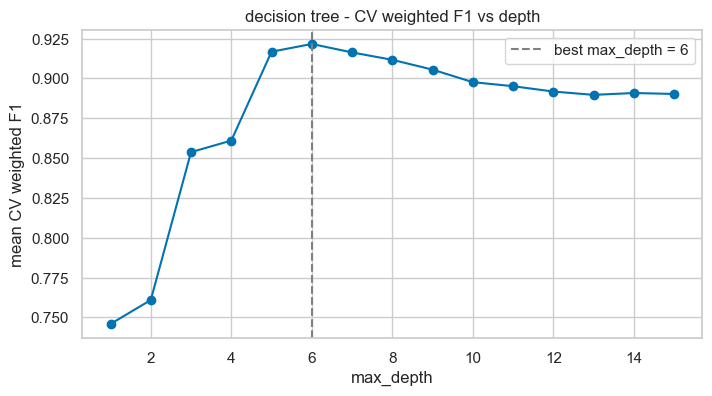

Decision Tree
accuracy: 0.8977  precision: 0.897  recall: 0.8977
f1: 0.897  macro f1: 0.8867  roc-auc: 0.9017

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       278
           1       0.88      0.83      0.85       152

    accuracy                           0.90       430
   macro avg       0.89      0.88      0.89       430
weighted avg       0.90      0.90      0.90       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[260  18]
 [ 26 126]]


In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# tuning max_depth with CV on the training set first
depth_scores = []
for d in range(1, 16):
    pipe = Pipeline([("preprocessor", clone(preprocessor)),
                     ("model", DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE))])
    depth_scores.append(cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="f1_weighted").mean())

best_depth = depth_scores.index(max(depth_scores)) + 1

plt.figure(figsize=(8, 4))
plt.plot(range(1, 16), depth_scores, marker="o")
plt.axvline(best_depth, color="grey", linestyle="--", label="best max_depth = " + str(best_depth))
plt.title("decision tree - CV weighted F1 vs depth")
plt.xlabel("max_depth")
plt.ylabel("mean CV weighted F1")
plt.legend()
plt.show()

dtree = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dtree_pipe = evaluate_model("Decision Tree", dtree, "A", "max_depth=" + str(best_depth) + " chosen by CV")

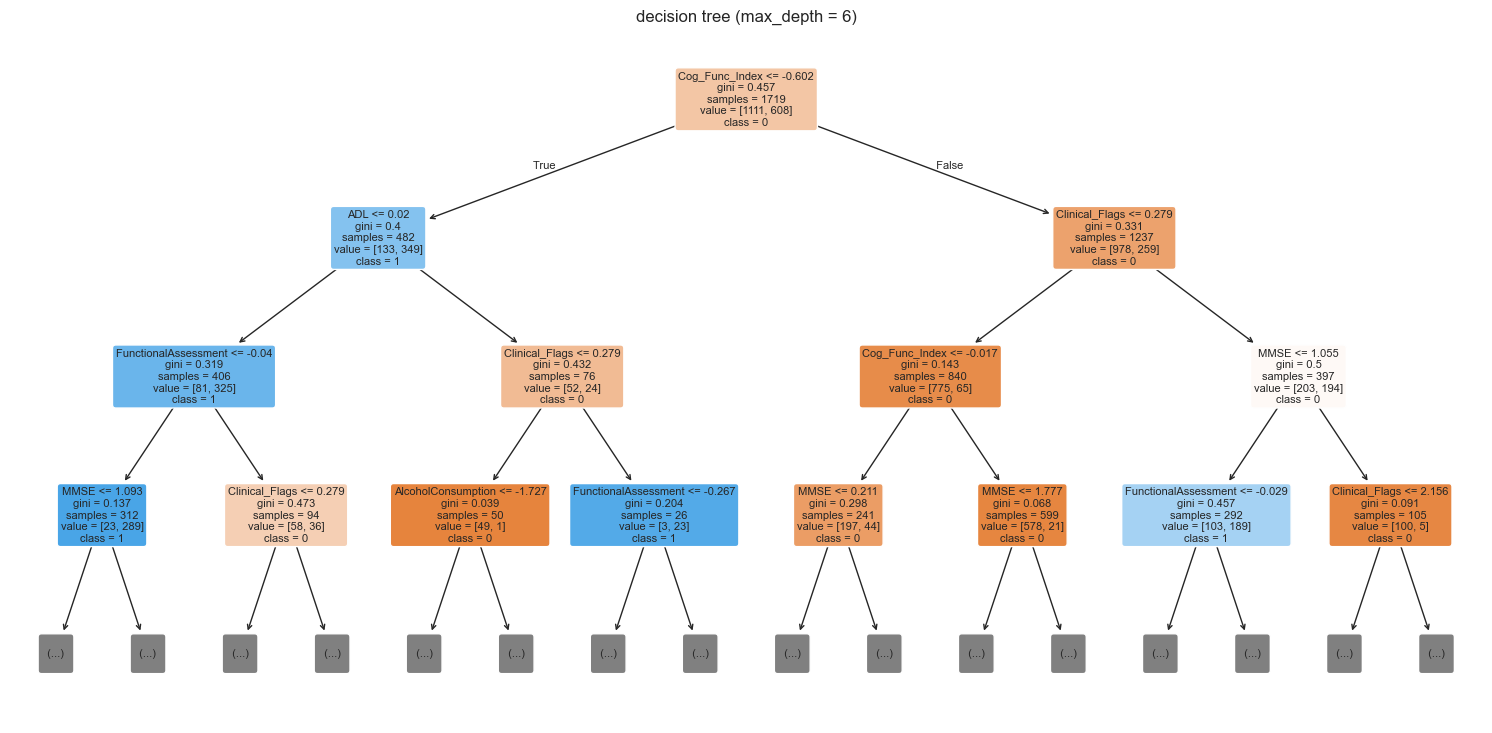

top 10 features used by the tree:
Cog_Func_Index                0.2935
Clinical_Flags                0.2607
MMSE                          0.1427
FunctionalAssessment          0.1342
ADL                           0.1239
AlcoholConsumption            0.0126
BMI                           0.0087
PhysicalActivity              0.0062
DietQuality                   0.0052
Ethnicity_African_American    0.0036
dtype: float64


In [28]:
# plotting the tree (only first 3 levels, the full thing is unreadable)
plt.figure(figsize=(19, 9))
plot_tree(dtree_pipe.named_steps["model"], max_depth=3, feature_names=FEATURE_NAMES,
          class_names=[str(c) for c in dtree_pipe.classes_], filled=True, rounded=True, fontsize=8)
plt.title("decision tree (max_depth = " + str(best_depth) + ")")
plt.show()

dt_importance = pd.Series(dtree_pipe.named_steps["model"].feature_importances_, index=FEATURE_NAMES)
print("top 10 features used by the tree:")
print(dt_importance.sort_values(ascending=False).head(10).round(4))

CV picks max_depth = 6 (CV weighted F1 about 0.92). The curve goes up steeply from a stump (0.745 at depth 1) to depth 5 or 6, then slowly goes down as the tree starts memorising the training set. This is the opposite of the cirrhosis notebook, where a single stump won. Here one split isn't enough because the rule involves several features at once.

It's the best Part A model on the test set (0.897 weighted F1), 5th out of 10 overall, and you can actually read the top of the tree like a doctor would:

- the root split is on Cog_Func_Index, our engineered feature. Patients with a low index are mostly Alzheimer's (349 of 482)
- patients with a high index and no clinical flags are almost all healthy (775 of 840)
- patients with a high index but at least one flag (memory complaints or behavioural problems) are about half and half (194 of 397), and the tree then uses MMSE and FunctionalAssessment to split them

The feature importance agrees. Cog_Func_Index (0.29), Clinical_Flags (0.26), MMSE (0.14), FunctionalAssessment (0.13) and ADL (0.12) add up to about 95% of the total. The rest is spread over noise columns like AlcoholConsumption (0.013). You can see this in the plot too, at level 3 there's a split on AlcoholConsumption for a node with 50 patients where 49 are already class 0, which is just the tree fitting noise.

The 65 Alzheimer's patients in the "high index, no flags" branch are the first sign of the missed diagnosis problem in section 23.4. They look healthy on the features that matter.

The usual caveat still applies, a single tree is high variance and the chosen depth depends on the CV seed. That instability is exactly what random forest, bagging and boosting are meant to fix.

## 14. Algorithm 5 - SVM

In [29]:
from sklearn.svm import SVC

# comparing kernels first
kernel_scores = {}
for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    pipe = Pipeline([("preprocessor", clone(preprocessor)),
                     ("model", SVC(kernel=kernel, probability=True, random_state=RANDOM_STATE))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="f1_weighted")
    kernel_scores[kernel] = scores.mean()
    print(kernel, ": CV f1 =", round(scores.mean(), 4), "+/-", round(scores.std(), 4))

best_kernel = max(kernel_scores, key=kernel_scores.get)
print("best kernel:", best_kernel)

svm = SVC(kernel=best_kernel, probability=True, random_state=RANDOM_STATE)
svm_pipe = evaluate_model("Support Vector Machine", svm, "A", "kernel='" + best_kernel + "'; probability=True for ROC-AUC")

linear : CV f1 = 0.8906 +/- 0.0158


rbf : CV f1 = 0.8812 +/- 0.0141


poly : CV f1 = 0.8651 +/- 0.0048


sigmoid : CV f1 = 0.8798 +/- 0.0149
best kernel: linear


Support Vector Machine
accuracy: 0.8953  precision: 0.8947  recall: 0.8953
f1: 0.8944  macro f1: 0.8835  roc-auc: 0.9361

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       278
           1       0.88      0.82      0.85       152

    accuracy                           0.90       430
   macro avg       0.89      0.88      0.88       430
weighted avg       0.89      0.90      0.89       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[261  17]
 [ 28 124]]


probability=True is needed because ROC-AUC needs scores and not just labels. It makes SVC do an internal Platt scaling with 5 fold CV, which is why this is the slowest model in Part A.

The kernel comparison is the main thing here. Linear wins (CV F1 0.891) with rbf (0.881) and sigmoid (0.880) just behind, and poly is worst (0.865). That's a bit surprising because the tree models later do much better than any linear model, so the real boundary is clearly not a straight line. Our guess is that RBF has the same problem as KNN: its kernel is built on the euclidean distance, and with about 30 noise columns that distance is mostly noise. C and gamma get tuned properly in section 21.

Something to remember for the final comparison: the SVM is only 6th on weighted F1 but it has the best ROC-AUC in Part A (0.936), so it ranks patients by risk better than its hard predictions suggest. Section 20 comes back to this.

Scaling is needed here too, for a different reason than KNN. The RBF kernel computes exp(-gamma * ||x - x'||^2), so one unscaled feature with a big range (like triglycerides) would saturate the kernel and the margin would be decided by that one variable.

## 15. Part A comparison

Rubric D2 (review 1): accuracy, weighted F1 and a confusion matrix for each algorithm, plus a comparison table.

In [30]:
part_a = pd.DataFrame(results).T
part_a = part_a[part_a["Part"] == "A"]
part_a = part_a.drop(columns=["Part", "Notes"]).astype(float)
part_a = part_a.sort_values("F1", ascending=False)
part_a.round(4)

,Accuracy,Precision,Recall,F1,Macro F1,ROC-AUC
Decision Tree,0.8977,0.8970,0.8977,0.8970,0.8867,0.9017
Support Vector Machine,0.8953,0.8947,0.8953,0.8944,0.8835,0.9361
Logistic Regression,0.8884,0.8876,0.8884,0.8877,0.8764,0.9335
K-Nearest Neighbors,0.8651,0.8708,0.8651,0.8598,0.8422,0.9283
Gaussian Naive Bayes,0.8442,0.8569,0.8442,0.8467,0.8358,0.9195


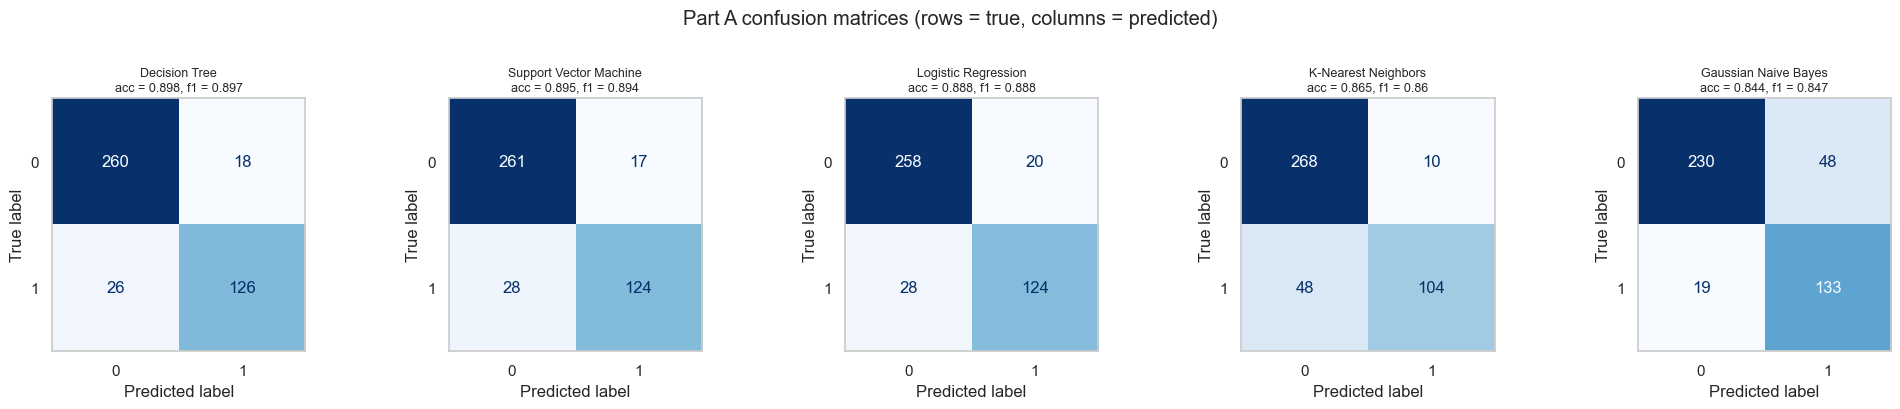

In [31]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
for i in range(5):
    plot_confusion(part_a.index[i], axes[i])
plt.suptitle("Part A confusion matrices (rows = true, columns = predicted)", y=1.04)
plt.tight_layout()
plt.show()

### Part A observations

The spread is smaller than in the cirrhosis notebook. Weighted F1 goes from 0.897 (decision tree) down to 0.847 (gaussian NB), and all five beat the majority class baseline (0.646 accuracy) easily, even the worst one is at 0.844.

The confusion matrices show what the accuracy hides. Look at the bottom row of each matrix (true Alzheimer's): for four of the five models most of the errors are missed Alzheimer's patients, not false alarms. Logistic regression misses 28 and has 20 false alarms, the SVM 28 vs 17, the decision tree 26 vs 18, and KNN 48 vs 10. Being the smaller class, Alzheimer's is the one that gets sacrificed. Gaussian NB is the exception like we said in section 12 (19 missed, 48 false alarms).

That's why macro F1 is in the table next to the required weighted metrics. The gap is small here (about 0.01 to 0.02) because the imbalance is mild, but it's still there for every model.

# Part B - review 2 algorithms

Five ensemble / neural network methods, same split and same preprocessing.

6. Random forest - bagged trees plus random feature subsets, which decorrelates the trees
7. AdaBoost - keeps reweighting the examples the ensemble gets wrong
8. Gradient boosting - each new tree is fit to the gradient of the loss
9. Bagging (decision tree base) - only bootstrap aggregation, used as the control for random forest
10. MLP - feed forward neural network

## 16. Algorithm 6 - Random forest

In [32]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_pipe = evaluate_model("Random Forest", rf, "B", "n_estimators=300; tuned further in Section 21")

Random Forest
accuracy: 0.9488  precision: 0.9487  recall: 0.9488
f1: 0.9487  macro f1: 0.9437  roc-auc: 0.9423

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.94      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[269   9]
 [ 13 139]]


10 trees -> 0.9085


25 trees -> 0.9309


50 trees -> 0.9333


100 trees -> 0.938


200 trees -> 0.9433


300 trees -> 0.9463


500 trees -> 0.9462


800 trees -> 0.9486


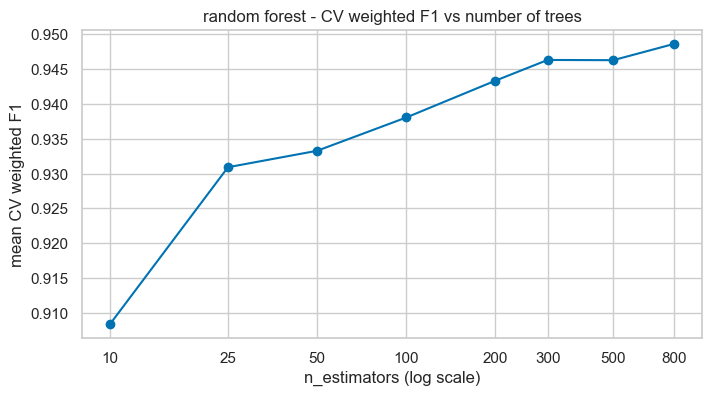

In [33]:
# how many trees do we actually need?
tree_counts = [10, 25, 50, 100, 200, 300, 500, 800]
tree_scores = []
for n in tree_counts:
    pipe = Pipeline([("preprocessor", clone(preprocessor)),
                     ("model", RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1))])
    tree_scores.append(cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="f1_weighted").mean())
    print(n, "trees ->", round(tree_scores[-1], 4))

plt.figure(figsize=(8, 4))
plt.plot(tree_counts, tree_scores, marker="o")
plt.xscale("log")
plt.xticks(tree_counts, tree_counts)
plt.title("random forest - CV weighted F1 vs number of trees")
plt.xlabel("n_estimators (log scale)")
plt.ylabel("mean CV weighted F1")
plt.show()

Performance goes up quickly until about 200 trees (0.909 with 10 trees, 0.943 with 200) and then stays flat (0.946 at 300, 0.949 at 800), which is the normal random forest behaviour. More trees reduce the variance of the vote but can't reduce bias, so after the plateau the extra trees don't buy much. So n_estimators isn't worth worrying about. 300 is inside the plateau, and unlike boosting, more trees never hurt (a forest doesn't overfit by adding more trees).

## 17. Algorithm 7 - AdaBoost

In [34]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
                         n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE)
ada_pipe = evaluate_model("AdaBoost", ada, "B", "Depth-1 stumps, n_estimators=200, learning_rate=0.5")

AdaBoost
accuracy: 0.907  precision: 0.9067  recall: 0.907
f1: 0.9068  macro f1: 0.8979  roc-auc: 0.9341

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       278
           1       0.87      0.86      0.87       152

    accuracy                           0.91       430
   macro avg       0.90      0.90      0.90       430
weighted avg       0.91      0.91      0.91       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[259  19]
 [ 21 131]]


AdaBoost uses depth 1 decision stumps, which is its usual weak learner. Each round fits one threshold and then gives more weight to the patients the ensemble is still getting wrong.

It ends up 4th (weighted F1 0.907), better than every Part A model but clearly behind the other tree ensembles (about 0.94 to 0.95). Our explanation: a sum of stumps is an additive model, each stump only looks at one feature, so it can't really learn interactions like "low functional score but no memory complaints". That puts it closer to the linear models (0.888 to 0.894) than to random forest. The reweighting also means the later rounds spend a lot of effort on the same few patients who look healthy on every feature but still have Alzheimer's, which is basically chasing noise.

## 18. Algorithms 8 and 9 - Gradient boosting and bagging

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(random_state=RANDOM_STATE)
gbm_pipe = evaluate_model("Gradient Boosting", gbm, "B", "sklearn GBM, default depth-3 trees; tuned in Section 21")

Gradient Boosting
accuracy: 0.9488  precision: 0.9488  recall: 0.9488
f1: 0.9488  macro f1: 0.944  roc-auc: 0.9464

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       278
           1       0.93      0.93      0.93       152

    accuracy                           0.95       430
   macro avg       0.94      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[267  11]
 [ 11 141]]


In [36]:
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
bagging_pipe = evaluate_model("Bagging (Decision Tree)", bagging, "B", "300 bootstrapped unpruned trees; the control for Random Forest")

Bagging (Decision Tree)
accuracy: 0.9419  precision: 0.9419  recall: 0.9419
f1: 0.9414  macro f1: 0.9355  roc-auc: 0.9467

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       278
           1       0.94      0.89      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[270   8]
 [ 17 135]]


Bagging vs random forest is basically a controlled experiment. Both fit 300 unpruned trees on bootstrap samples. The only difference is that random forest also picks a random subset of features at each split (max_features='sqrt') while bagging looks at all of them.

So comparing the two rows in the final table shows the value of feature subsampling on its own. Random forest comes out slightly ahead (0.949 vs 0.941 weighted F1), but that's only about 3 patients out of 430 so we can't claim much. It makes sense that the effect is small here: with all features available, every bagged tree grabs Cog_Func_Index or Clinical_Flags at the top and the trees end up correlated, but since there are only a handful of useful features, random forest's trees also keep finding the same ones.

Gradient boosting vs AdaBoost: both boost one tree after another, but GBM fits each new depth 3 tree to the gradient of the loss instead of to reweighted examples, and shrinks each tree's contribution by the learning rate.

Here that makes a big difference. GBM gets 0.949 weighted F1 vs 0.907 for AdaBoost, and it misses only 11 Alzheimer's patients vs 21. The depth 3 trees can learn interactions between features (two or three conditions at once), which the stumps in AdaBoost can't, and that seems to be exactly what this dataset needs. GBM and random forest end up with the same accuracy (0.9488) which is kind of a coincidence, they make different mistakes (GBM misses fewer Alzheimer's patients, random forest has fewer false alarms).

## 19. Algorithm 10 - MLP (neural network)

In [37]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPClassifier

# some MLP settings (esp. in the random search later) don't fully converge and spam warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# not using early_stopping, it would hold out another 10% of the training set just for stopping.
# using the alpha (L2) penalty and n_iter_no_change on the training loss instead
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                    alpha=1e-3, max_iter=2000, n_iter_no_change=25, random_state=RANDOM_STATE)
mlp_pipe = evaluate_model("MLP (Neural Network)", mlp, "B", "(64, 32) ReLU, adam, alpha=1e-3; tuned in Section 21")

MLP (Neural Network)
accuracy: 0.8558  precision: 0.8546  recall: 0.8558
f1: 0.8549  macro f1: 0.8403  roc-auc: 0.907

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       278
           1       0.81      0.77      0.79       152

    accuracy                           0.86       430
   macro avg       0.85      0.84      0.84       430
weighted avg       0.85      0.86      0.85       430

confusion matrix (rows = true 0/1, cols = predicted 0/1):
[[251  27]
 [ 35 117]]


(16,)  params ~ 656   CV f1 = 0.8327 +/- 0.0222


(32,)  params ~ 1312   CV f1 = 0.8506 +/- 0.0176


(64,)  params ~ 2624   CV f1 = 0.8559 +/- 0.0094


(32, 16)  params ~ 1808   CV f1 = 0.8428 +/- 0.0113


(64, 32)  params ~ 4640   CV f1 = 0.8507 +/- 0.0113


(128, 64)  params ~ 13376   CV f1 = 0.857 +/- 0.0126


(64, 32, 16)  params ~ 5136   CV f1 = 0.8625 +/- 0.0135


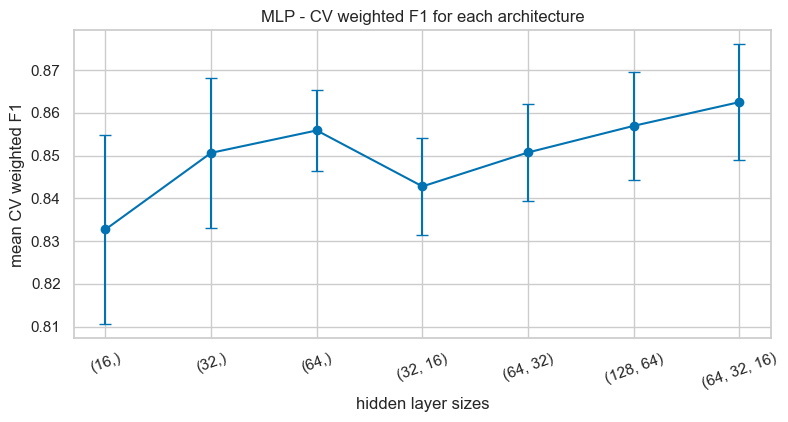

In [38]:
# does a bigger network help?
architectures = [(16,), (32,), (64,), (32, 16), (64, 32), (128, 64), (64, 32, 16)]
arch_names = []
arch_means = []
arch_stds = []
for hidden in architectures:
    pipe = Pipeline([("preprocessor", clone(preprocessor)),
                     ("model", MLPClassifier(hidden_layer_sizes=hidden, max_iter=2000, n_iter_no_change=25, random_state=RANDOM_STATE))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="f1_weighted")

    # rough number of weights in the network (binary so the output layer is just 1 unit)
    sizes = [len(FEATURE_NAMES)] + list(hidden) + [1]
    n_params = 0
    for j in range(len(sizes) - 1):
        n_params += sizes[j] * sizes[j + 1]

    print(hidden, " params ~", n_params, "  CV f1 =", round(scores.mean(), 4), "+/-", round(scores.std(), 4))
    arch_names.append(str(hidden))
    arch_means.append(scores.mean())
    arch_stds.append(scores.std())

plt.figure(figsize=(9, 4))
plt.errorbar(arch_names, arch_means, yerr=arch_stds, marker="o", capsize=4)
plt.title("MLP - CV weighted F1 for each architecture")
plt.xlabel("hidden layer sizes")
plt.ylabel("mean CV weighted F1")
plt.xticks(rotation=20)
plt.show()

The architecture sweep is pretty flat. Everything from a single 16 unit layer up to (128, 64) scores between 0.833 and 0.863 CV weighted F1, with fold standard deviations of 0.009 to 0.022. The bigger networks do a bit better but the gaps are only about one or two standard deviations. (128, 64) has over 13000 weights fitted on 1719 training rows, while (16,) has 656.

It still ends up 9th out of 10 on the test set (0.855), only above gaussian NB, so we should say that plainly. Our guess is that most of its capacity goes into fitting the ~30 noise columns, and a neural network doesn't have an easy way to "ignore" a feature the way a tree does by just never splitting on it. For tabular data with a couple thousand rows, tree ensembles are still the sensible default, and this is a clear example of that.